Parsing output.txt file...

Found 5 models

Model Performance Summary:

Random Forest: No training data

CNN:
  Total epochs: 47
  Best training F1: 0.8247 (epoch 27)
  Best training accuracy: 0.8320 (epoch 29)
  Final test accuracy: 0.8240
  Final training loss: 0.0849
  Per-class accuracy:
    ADLs: 0.8750
    Aggregates: 0.7222
    Droplets: 0.8636
    Gels: 0.7778
    Solutions: 1.0000
  Per-class precision:
    ADLs: 0.5400
    Aggregates: 0.8400
    Droplets: 0.8500
    Gels: 0.8800
    Solutions: 1.0000
  Per-class recall:
    ADLs: 0.8800
    Aggregates: 0.7200
    Droplets: 0.8600
    Gels: 0.7800
    Solutions: 1.0000
  Per-class F1-score:
    ADLs: 0.6700
    Aggregates: 0.7800
    Droplets: 0.8600
    Gels: 0.8200
    Solutions: 1.0000

DenseNet121:
  Total epochs: 54
  Best training F1: 0.9575 (epoch 34)
  Best training accuracy: 0.9760 (epoch 14)
  Final test accuracy: 0.9760
  Final training loss: 0.0077
  Per-class accuracy:
    ADLs: 0.8750
    Aggregates: 0.9444
    D

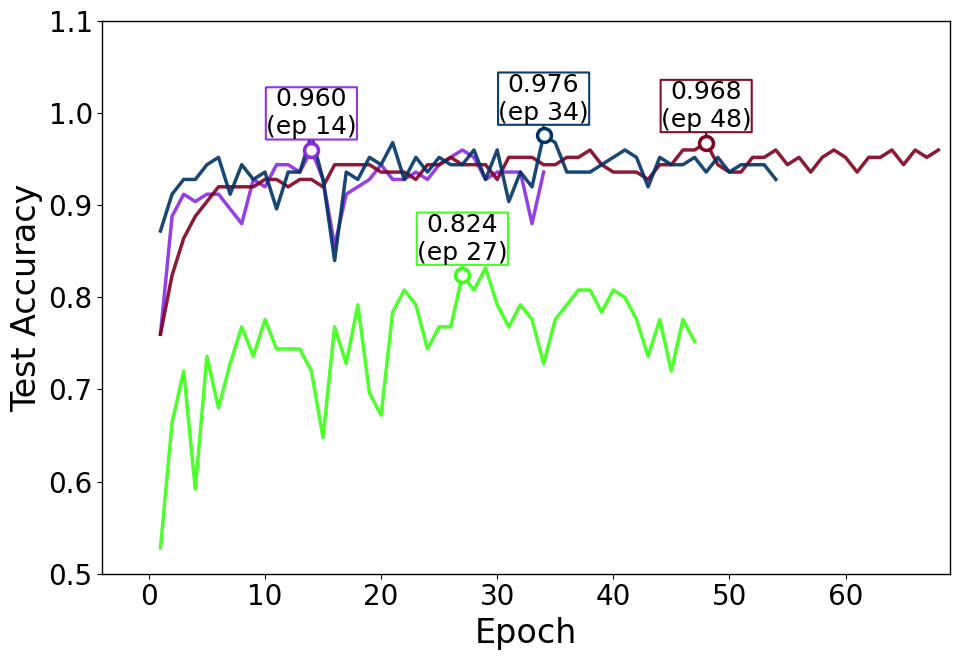

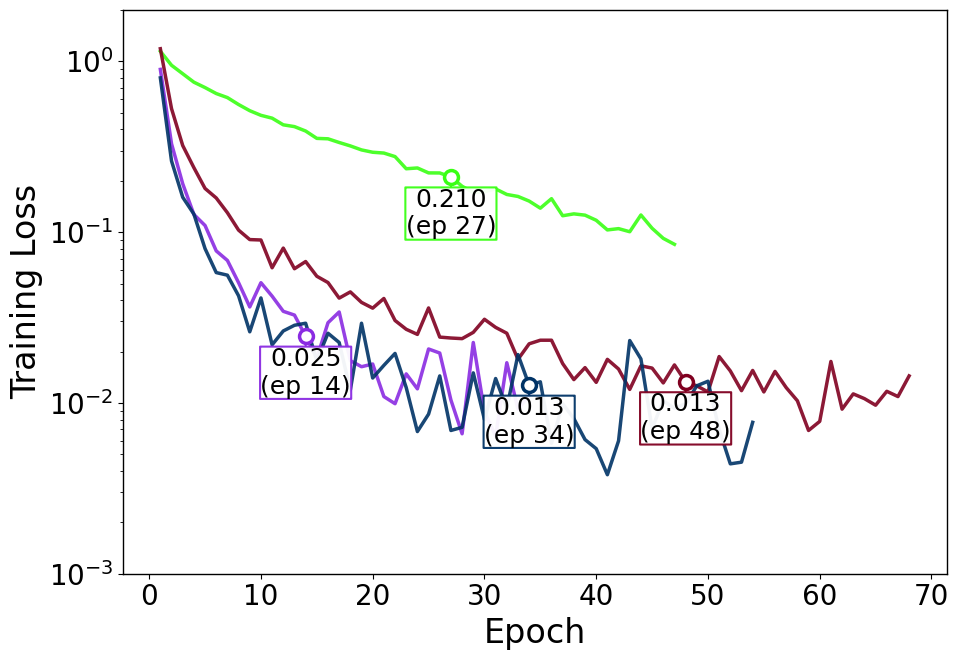

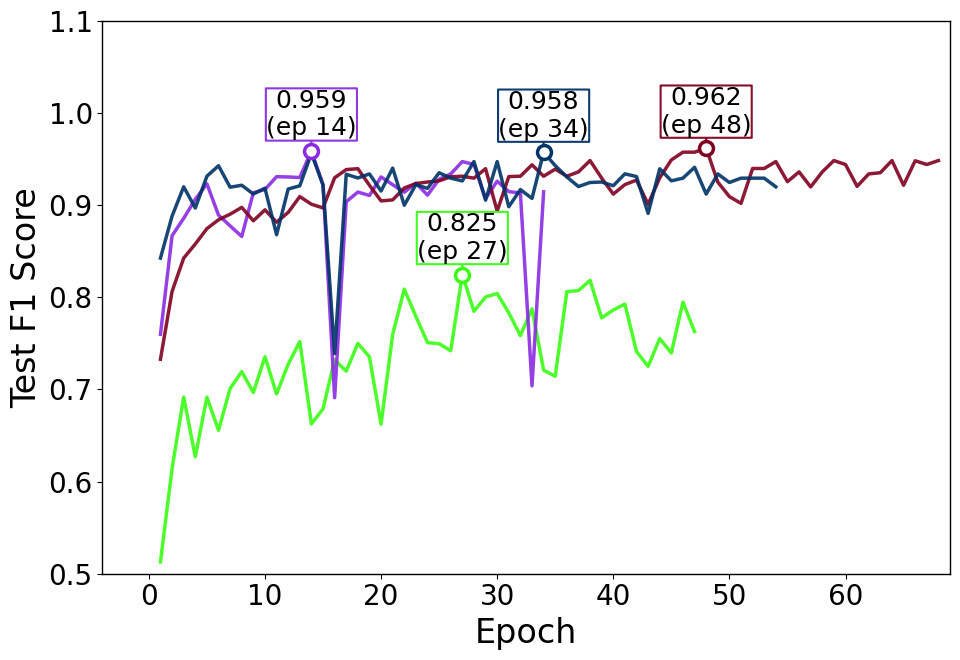


2. Creating overall accuracy comparison...


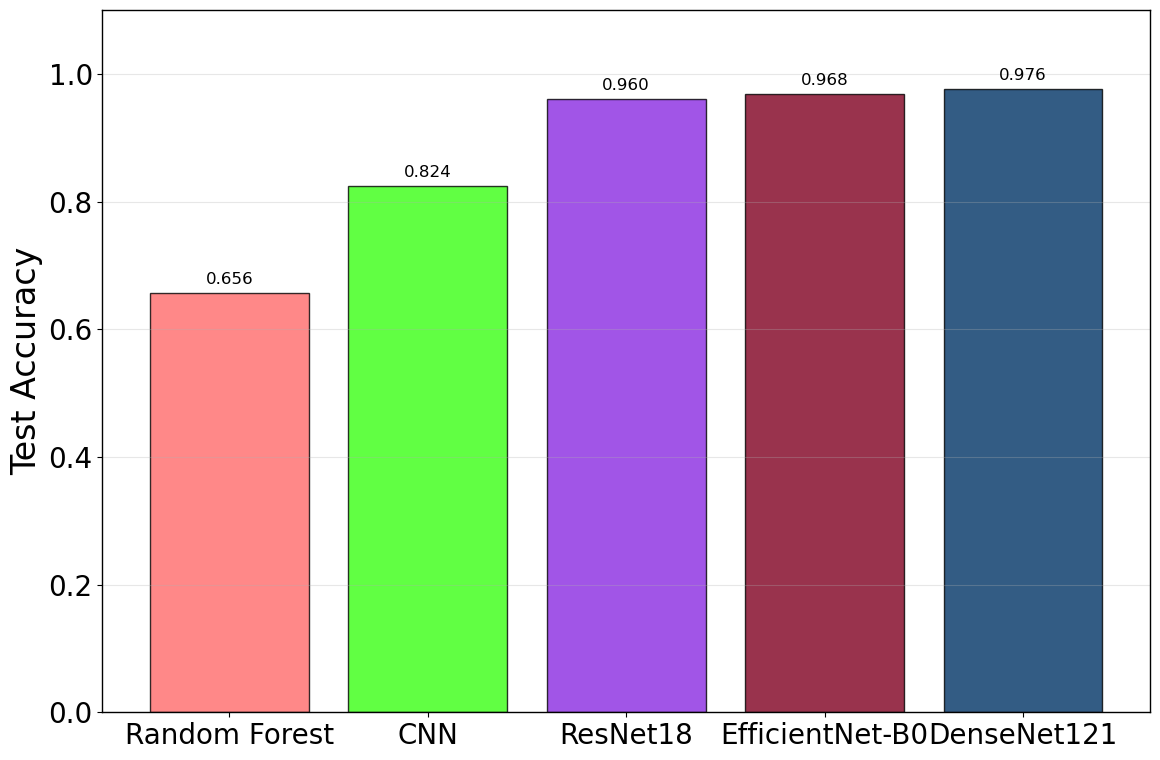


3. Creating per-class accuracy comparison...


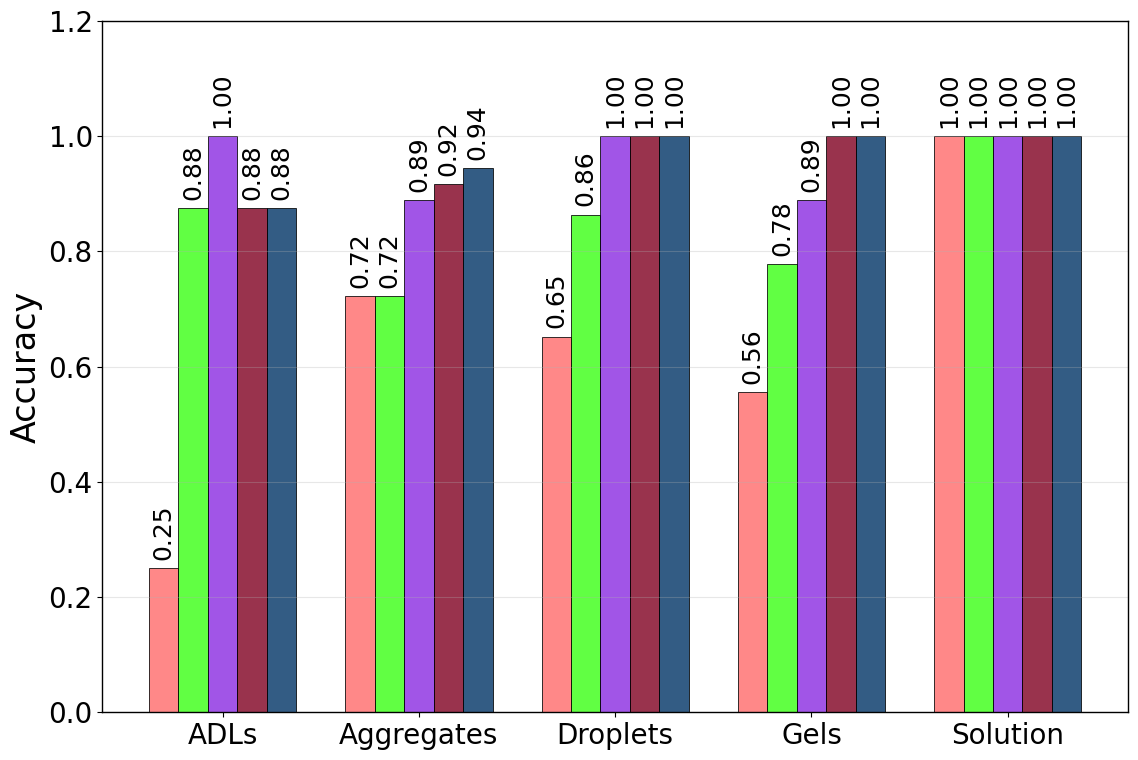


4. Creating per-class precision comparison...


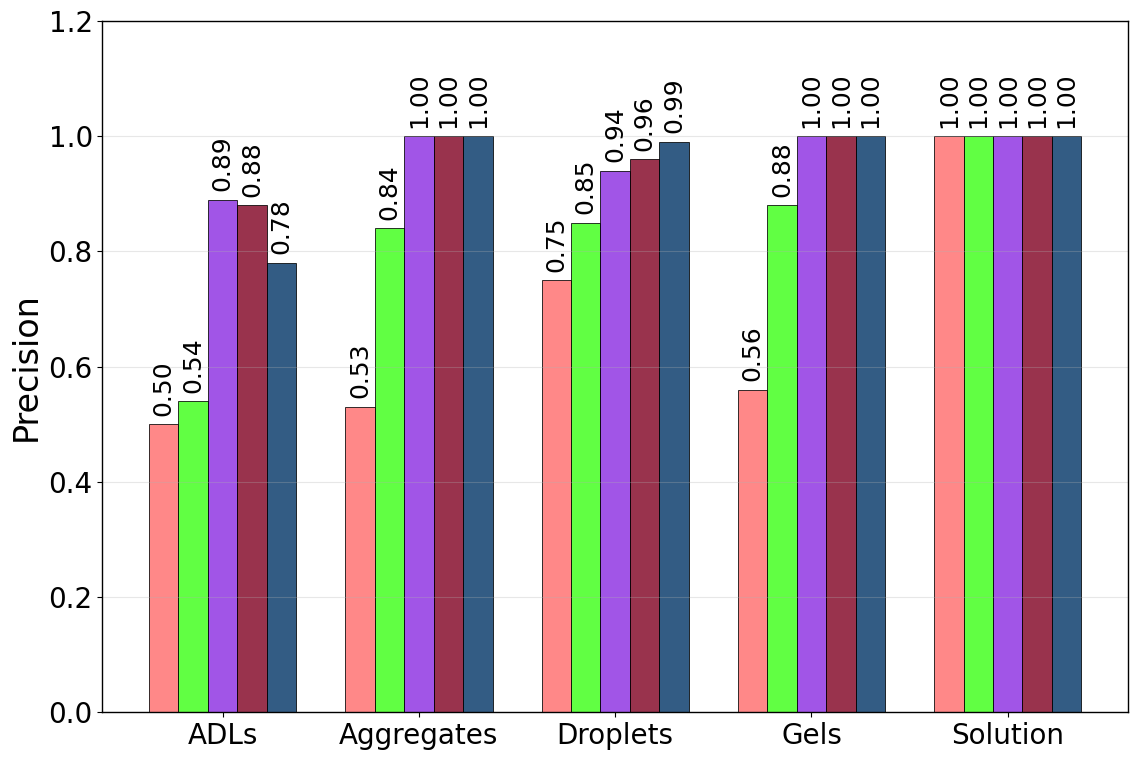


5. Creating per-class recall comparison...


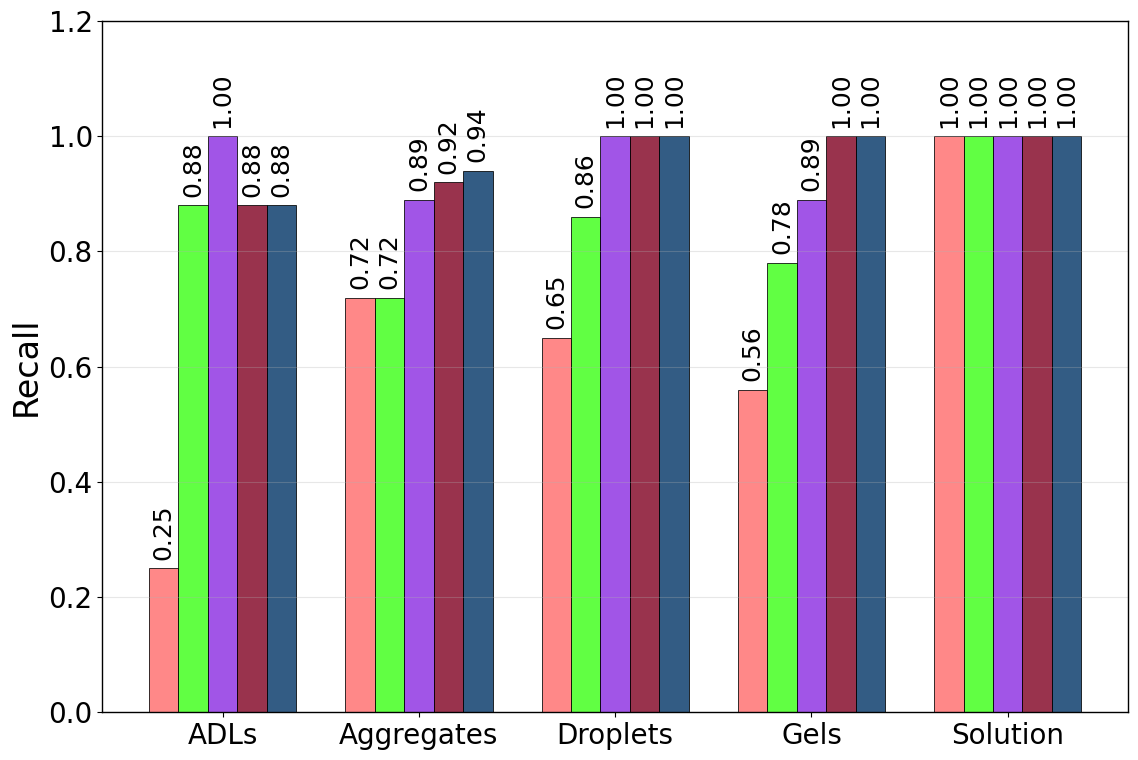


6. Creating per-class F1-score comparison...


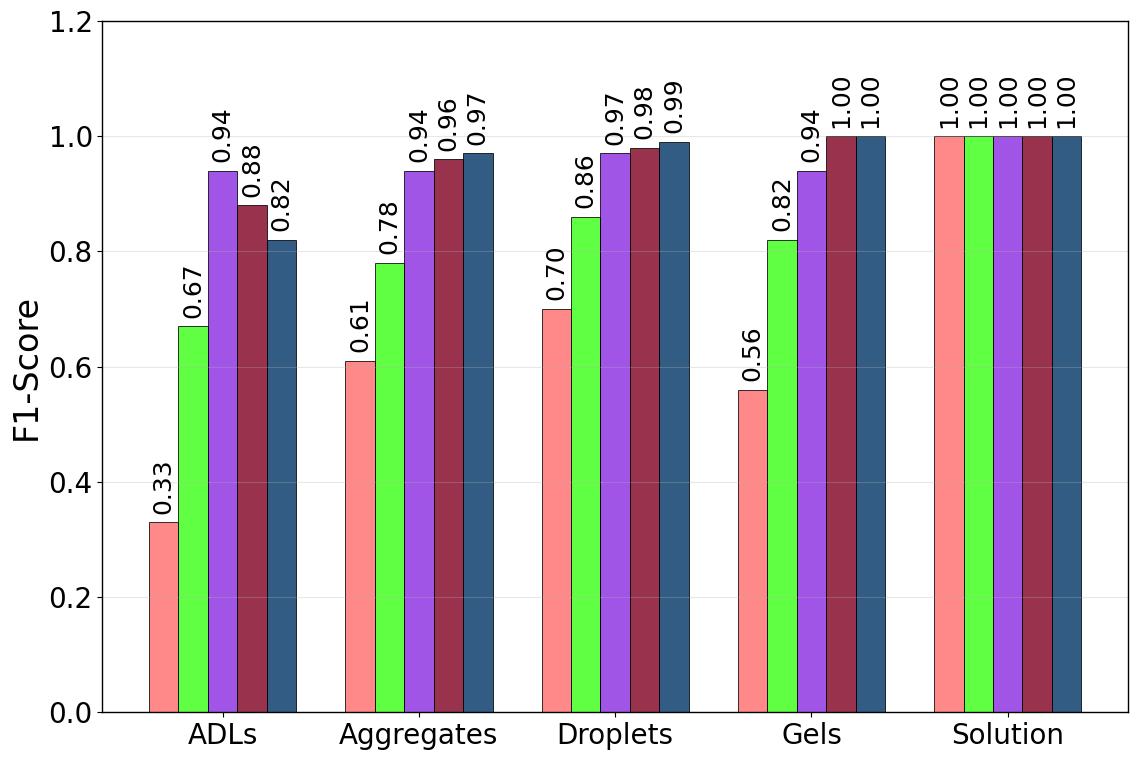


All plots generated successfully!


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import re
from collections import defaultdict
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset



# --- STYLE ---
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['grid.alpha'] = 0.3

# --- CONSTANTS (marker/label geometry) ---
BEST_MARKER_SIZE = 100            # points^2 (same as your scatter)
BBOX_PAD = 0.01                    # bbox pad used in annotate
EXTRA_GAP_PTS = 2.0               # tiny breathing gap between marker and box

# Convert marker area (pts^2) to an approximate radius in pts
MARKER_RADIUS_PTS = (BEST_MARKER_SIZE / np.pi) ** 0.5

# Model name mapping and colors
MODEL_NAME_MAP = {
    'RandomForest': 'Random Forest',
    'SimpleCNN': 'CNN',
    'ResNet': 'ResNet18',
    'DenseNet': 'DenseNet121',
    'EfficientNet': 'EfficientNet-B0'
}

MODEL_COLORS = {
    'Random Forest': '#FF6B6B',
    'CNN': '#39FF14',
    'ResNet18': '#8A2BE2',
    'DenseNet121': '#003366',
    'EfficientNet-B0': '#800020'
}

# Class name mapping
CLASS_NAME_MAP = {
    'Solutions': 'Solution'
}


# Desired legend order
LEGEND_ORDER = ['Random Forest', 'CNN', 'ResNet18', 'EfficientNet-B0', 'DenseNet121']

def sort_models_by_legend_order(models):
    return sorted(models, key=lambda x: LEGEND_ORDER.index(x) if x in LEGEND_ORDER else len(LEGEND_ORDER))

def parse_output_file(filename='output.txt'):
    models_data = {}
    current_model = None
    
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        
        # Detect model training start
        for raw_name in MODEL_NAME_MAP.keys():
            if f'Training {raw_name}' in line:
                current_model = MODEL_NAME_MAP[raw_name]
                if current_model not in models_data:
                    models_data[current_model] = {
                        'epochs': [], 'loss': [], 'accuracy': [], 'f1': [],
                        'test_acc': 0.0,
                        'per_class_acc': {}, 'per_class_precision': {},
                        'per_class_recall': {}, 'per_class_f1': {},
                        'color': MODEL_COLORS[current_model]
                    }
                break
        
        # Detect classification report (alternative model identifier)
        if 'Classification Report:' in line:
            for raw_name in MODEL_NAME_MAP.keys():
                if raw_name in line:
                    current_model = MODEL_NAME_MAP[raw_name]
                    if current_model not in models_data:
                        models_data[current_model] = {
                            'epochs': [], 'loss': [], 'accuracy': [], 'f1': [],
                            'test_acc': 0.0,
                            'per_class_acc': {}, 'per_class_precision': {},
                            'per_class_recall': {}, 'per_class_f1': {},
                            'color': MODEL_COLORS[current_model]
                        }
                    break
        
        # Parse epoch line
        if current_model and 'Epoch' in line and 'Loss:' in line:
            m = re.search(r'Epoch (\d+)/\d+ - Loss: ([\d.]+) - Acc: ([\d.]+) - F1: ([\d.]+)', line)
            if m:
                epoch = int(m.group(1))
                loss = float(m.group(2))
                acc = float(m.group(3))
                f1 = float(m.group(4))
                models_data[current_model]['epochs'].append(epoch)
                models_data[current_model]['loss'].append(loss)
                models_data[current_model]['accuracy'].append(acc)
                models_data[current_model]['f1'].append(f1)
        
        # Parse overall accuracy and F1
        if current_model and 'Overall Accuracy:' in line:
            m = re.search(r'Overall Accuracy: ([\d.]+), F1: ([\d.]+)', line)
            if m:
                models_data[current_model]['test_acc'] = float(m.group(1))
                models_data[current_model]['final_f1'] = float(m.group(2))
        
        # Parse per-class accuracy
        if current_model and 'Per-class accuracy:' in line:
            i += 1
            while i < len(lines) and lines[i].strip() and not lines[i].strip().startswith('Saved'):
                class_line = lines[i].strip()
                m = re.search(r'(\w+): ([\d.]+)', class_line)
                if m:
                    class_name = m.group(1)
                    class_acc = float(m.group(2))
                    models_data[current_model]['per_class_acc'][class_name] = class_acc
                i += 1
            continue
        
        # Parse classification report metrics
        if current_model and all(k in line for k in ['precision', 'recall', 'f1-score', 'support']):
            i += 1
            while i < len(lines) and (not lines[i].strip() or '===' in lines[i]):
                i += 1
            while i < len(lines):
                class_line = lines[i].strip()
                if not class_line:
                    break
                if any(keyword in class_line for keyword in ['accuracy', 'macro avg', 'weighted avg']):
                    break
                parts = class_line.split()
                if len(parts) >= 4:
                    class_name = parts[0]
                    try:
                        precision = float(parts[1])
                        recall = float(parts[2])
                        f1_score = float(parts[3])
                        models_data[current_model]['per_class_precision'][class_name] = precision
                        models_data[current_model]['per_class_recall'][class_name] = recall
                        models_data[current_model]['per_class_f1'][class_name] = f1_score
                    except (ValueError, IndexError):
                        pass
                i += 1
            continue
        
        i += 1
    
    return models_data

def _attach_value_box(ax, x, y, text, color, place_above=True):
    """
    Attach a value box to the marker without overlap.
    Uses a small vertical offset in 'points' so it's independent of axis scale.
    Auto-adds a short connector line so it visually touches the point.
    """
    sign = +1 if place_above else -1
    approx_pad_pts = BBOX_PAD * 5.0  # rough pad -> points
    y_offset_pts = sign * (MARKER_RADIUS_PTS + approx_pad_pts + EXTRA_GAP_PTS)
    
    ax.annotate(
        text,
        xy=(x, y),
        xytext=(0, y_offset_pts),
        textcoords='offset points',
        ha='center',
        va='bottom' if place_above else 'top',
        fontsize=18,
        bbox=dict(boxstyle=f'round,pad={BBOX_PAD}',
                  facecolor='white', alpha=0.95,
                  edgecolor=color, linewidth=1.5),
        arrowprops=dict(arrowstyle='-',
                        color=color, lw=1.5,
                        shrinkA=0, shrinkB=0,
                        relpos=(0.5, 0.0 if place_above else 1.0))
    )

def create_training_plot(models_data, metric, ylabel, title, log_scale=False, filename_suffix=""):
    fig, ax = plt.subplots(figsize=(10, 7))
    
    sorted_models = sort_models_by_legend_order([m for m in models_data.keys() if models_data[m]['epochs']])
    
    annotations_data = []
    for model_name in sorted_models:
        data = models_data[model_name]
        ax.plot(data['epochs'], data[metric], label=model_name, color=data['color'], linewidth=2.5, alpha=0.9)
        
      #  best_idx = np.argmin(data[metric]) if metric == 'loss' else np.argmax(data[metric])
        if data['f1']:
            best_idx = int(np.argmax(data['f1']))
        else:
            best_idx = len(data['epochs']) - 1  # fallback if F1 missing

        
        mark_value = data[metric][best_idx]
        mark_epoch = data['epochs'][best_idx]
        
        annotations_data.append((mark_epoch, mark_value, model_name, data))
        
        ax.scatter(mark_epoch, mark_value, color=data['color'],
                   s=BEST_MARKER_SIZE, facecolors='white',
                   edgecolors=data['color'], linewidth=2.5, zorder=5)
    
    # ADD X AND Y LABELS
    ax.set_xlabel('Epoch', fontsize=24)
    ax.set_ylabel(ylabel, fontsize=24)
    
    if log_scale:
        ax.set_yscale('log')
        
    if metric == 'loss' and log_scale:
        ax.set_ylim(1e-3, 2)
    elif not log_scale:
        if metric in ('accuracy', 'f1'):
            ax.set_ylim(0.5, 1.1)
            ax.set_xlim(-4, 69)
    
    # Distances for crowding
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    crowded_points = set()
    
    # FOR F1 AND LOSS: DISABLE CROWDING DETECTION - ALL BOXES STICK TO POINTS
    if metric in ['loss', 'f1']:
        # Don't detect crowding for loss and f1 - all annotations will stick directly to points
        crowded_points = set()
    else:
        # Only use crowding detection for accuracy
        if len(annotations_data) > 1:
            for i, (e1, v1, n1, _) in enumerate(annotations_data):
                for j, (e2, v2, n2, _) in enumerate(annotations_data):
                    if i >= j: continue
                    epoch_range = max(xlim[1] - xlim[0], 1e-9)
                    if log_scale and v1 > 0 and v2 > 0:
                        vrange = max(np.log10(ylim[1]) - np.log10(ylim[0]), 1e-9)
                        vdist = abs(np.log10(v1) - np.log10(v2)) / vrange
                    else:
                        vrange = max(ylim[1] - ylim[0], 1e-9)
                        vdist = abs(v1 - v2) / vrange
                    edist = abs(e1 - e2) / epoch_range
                    if (edist**2 + vdist**2) ** 0.5 < 0.05:
                        crowded_points.update([n1, n2])
    
    crowded = [(e, v, n, d) for e, v, n, d in annotations_data if n in crowded_points]
    non_crowded = [(e, v, n, d) for e, v, n, d in annotations_data if n not in crowded_points]
    
    # --- Orientation rule by metric ---
    # accuracy -> above, f1 -> above, loss -> below
    def default_place_above(m):
        return True if m in ['accuracy', 'f1'] else False
    
    # Non-crowded labels: attach outside marker with metric-based orientation
    for x0, y0, name, data in non_crowded:
        place_above = default_place_above(metric)
        
        # Safety: flip if too close to top/bottom border
        # BUT: for loss, ALWAYS keep boxes below (never flip)
        if metric != 'loss':
            y0min, y0max = ylim
            margin = 0.02 * (y0max - y0min)
            if place_above and y0 > y0max - margin:
                place_above = False
            if (not place_above) and y0 < y0min + margin:
                place_above = True
        
        _attach_value_box(ax, x0, y0, f'{y0:.3f}\n(ep {x0})', data['color'], place_above=place_above)
    
    # Crowded points: keep zoom insets (unchanged)
    if crowded:
        if metric in ['accuracy', 'f1']:
            inset_positions = [
                (0.05, 0.05, 'lower left'),
                (0.35, 0.05, 'lower left'),
                (0.65, 0.05, 'lower left'),
                (0.05, 0.28, 'lower left'),
                (0.35, 0.28, 'lower left'),
            ]
        else:
            inset_positions = [
                (0.60, 0.65, 'upper left'),
                (0.25, 0.65, 'upper left'),
                (0.60, 0.35, 'upper left'),
                (0.25, 0.35, 'upper left'),
                (0.60, 0.05, 'upper left'),
            ]
        
        for idx, (x0, y0, name, data) in enumerate(crowded):
            if idx >= len(inset_positions): break
            bbox_x, bbox_y, loc = inset_positions[idx]
            
            axins = inset_axes(ax, width="22%", height="22%",
                               loc=loc, bbox_to_anchor=(bbox_x, bbox_y, 1, 1),
                               bbox_transform=ax.transAxes, borderpad=0)
            
            axins.plot(data['epochs'], data[metric], color=data['color'], linewidth=2.5, alpha=0.9)
            axins.scatter(x0, y0, color=data['color'], s=BEST_MARKER_SIZE*0.8,
                          facecolors='white', edgecolors=data['color'], linewidth=2.5, zorder=5)
            
            # Keep inset text inside; orientation rule isn't critical within the inset
            axins.text(0.5, 0.95, f'{y0:.3f}\n(ep {x0})',
                       transform=axins.transAxes, fontsize=11,
                       ha='center', va='top',
                       bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                                 alpha=0.95, edgecolor=data['color'], linewidth=1.5))
            
            span = max(len(data['epochs']) * 0.15, 5)
            zxmin = max(0, x0 - span/2); zxmax = min(max(data['epochs']), x0 + span/2)
            axins.set_xlim(zxmin, zxmax)
            
            idxs = [i for i, e in enumerate(data['epochs']) if zxmin <= e <= zxmax]
            if idxs:
                vals = [data[metric][i] for i in idxs]
                if log_scale:
                    lv = [np.log10(v) if v > 0 else 0 for v in vals]
                    lrange = max(lv) - min(lv); lcenter = np.log10(y0) if y0 > 0 else 0
                    zspan = max(lrange*1.3, 0.1)
                    axins.set_ylim(10**(lcenter - zspan/2), 10**(lcenter + zspan/2))
                    axins.set_yscale('log')
                else:
                    vr = max(vals) - min(vals); zspan = max(vr*1.3, 0.02)
                    axins.set_ylim(y0 - zspan/2, y0 + zspan/2)
            
            axins.grid(True, alpha=0.3, linewidth=0.5)
            axins.tick_params(labelsize=9)
            for s in axins.spines.values():
                s.set_edgecolor(data['color']); s.set_linewidth(2)
            
            mark_inset(ax, axins, loc1=2, loc2=4, fc="none",
                       ec=data['color'], linestyle='--', linewidth=1.2, alpha=0.7)
    
    # #ax.legend(fontsize=18, framealpha=1,
    #           ncol=len(sorted_models),
    #           bbox_to_anchor=(0., 1.02, 1., .102),
    #           loc='lower left', mode='expand', borderaxespad=0.)
    
    plt.tight_layout()
    plt.savefig(f'{metric}_comparison{filename_suffix}.pdf', dpi=600, bbox_inches='tight')
    plt.show()

def create_overall_accuracy_plot(models_data):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    models = sort_models_by_legend_order([m for m in models_data.keys() if models_data[m]['test_acc'] > 0])
    accuracies = [models_data[m]['test_acc'] for m in models]
    colors = [models_data[m]['color'] for m in models]
    
    bars = ax.bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
    
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2.0, h + 0.01,
                f'{h:.3f}', ha='center', va='bottom', fontsize=12)
    
    ax.set_ylabel('Test Accuracy', fontsize=24)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=20)
    
    # #ax.legend(bars, models, fontsize=20, framealpha=0.9,
    #           ncol=len(models),
    #           bbox_to_anchor=(0., 1.02, 1., .102),
    #           loc='lower left', mode='expand', borderaxespad=0.)
    
    plt.tight_layout()
    plt.savefig('overall_accuracy_comparison.pdf', dpi=600, bbox_inches='tight')
    plt.show()

def create_per_class_metric_plot(models_data, metric_name, metric_key, filename):
    all_classes = set()
    for model_data in models_data.values():
        all_classes.update(model_data[metric_key].keys())
    classes = sorted(list(all_classes))
    classes = [CLASS_NAME_MAP.get(cls, cls) for cls in classes]
    
    models = sort_models_by_legend_order([m for m in models_data.keys() if models_data[m][metric_key]])
    
    if not classes or not models:
        print(f"No per-class {metric_name} data found.")
        return
    
    plt.figure(figsize=(14, 8))
    x = np.arange(len(classes))
    width = 0.15
    
    for j, model in enumerate(models):
        reverse_map = {v: k for k, v in CLASS_NAME_MAP.items()}
        values = [models_data[model][metric_key].get(reverse_map.get(cls, cls), 0) for cls in classes]


        
        color = models_data[model]['color']
        bars = plt.bar(x + j * width, values, width, label=model,
                       color=color, alpha=0.8, edgecolor='black', linewidth=0.7)
        
        for k, bar in enumerate(bars):
            h = bar.get_height()
            if h > 0:
                plt.text(bar.get_x() + bar.get_width()/2., h + 0.015,
                         f'{h:.2f}', ha='center', va='bottom',
                         fontsize=18, rotation=90)
    
    plt.ylabel(metric_name, fontsize=24)
    plt.xticks(x + width * (len(models)-1)/2, classes, fontsize=20)
    plt.yticks(fontsize=20)
    # plt.legend(fontsize=16, framealpha=0.9,
    #            ncol=len(models),
    #            bbox_to_anchor=(0., 1.02, 1., .102),
    #            loc='lower left', mode='expand', borderaxespad=0.)
    plt.grid(True, alpha=0.3, axis='y')
    plt.ylim(0, 1.2)
    
    plt.tight_layout()
    plt.subplots_adjust(right=0.82)
    plt.savefig(filename, dpi=600, bbox_inches='tight')
    plt.show()

def create_per_class_accuracy_plot(models_data):
    create_per_class_metric_plot(models_data, 'Accuracy', 'per_class_acc',
                                 'per_class_accuracy_comparison.pdf')

def print_summary(models_data):
    print("\nModel Performance Summary:")
    print("=" * 80)
    
    for model_name, data in models_data.items():
        if not data['epochs']:
            print(f"\n{model_name}: No training data")
            continue
        
        best_f1_idx = np.argmax(data['f1']) if data['f1'] else 0
        best_acc_idx = np.argmax(data['accuracy']) if data['accuracy'] else 0
        final_loss = data['loss'][-1] if data['loss'] else 0
        
        print(f"\n{model_name}:")
        print(f"  Total epochs: {len(data['epochs'])}")
        if data['f1']:
            print(f"  Best training F1: {max(data['f1']):.4f} (epoch {best_f1_idx + 1})")
        if data['accuracy']:
            print(f"  Best training accuracy: {max(data['accuracy']):.4f} (epoch {best_acc_idx + 1})")
        print(f"  Final test accuracy: {data['test_acc']:.4f}")
        if data['loss']:
            print(f"  Final training loss: {final_loss:.4f}")
        
        if data['per_class_acc']:
            print(f"  Per-class accuracy:")
            for cls, acc in sorted(data['per_class_acc'].items()):
                print(f"    {cls}: {acc:.4f}")
        
        if data['per_class_precision']:
            print(f"  Per-class precision:")
            for cls, prec in sorted(data['per_class_precision'].items()):
                print(f"    {cls}: {prec:.4f}")
        
        if data['per_class_recall']:
            print(f"  Per-class recall:")
            for cls, rec in sorted(data['per_class_recall'].items()):
                print(f"    {cls}: {rec:.4f}")
        
        if data['per_class_f1']:
            print(f"  Per-class F1-score:")
            for cls, f1 in sorted(data['per_class_f1'].items()):
                print(f"    {cls}: {f1:.4f}")

# --- MAIN ---
if __name__ == "__main__":
    print("Parsing output.txt file...")
    models_data = parse_output_file('output.txt')
    
    print(f"\nFound {len(models_data)} models")
    print_summary(models_data)
    
    print("\n" + "="*60)
    print("GENERATING PLOTS")
    print("="*60)
    
    # Training curves
    print("\n1. Creating training curve plots...")
    create_training_plot(models_data, 'accuracy', 'Test Accuracy', 'Test Accuracy')
    create_training_plot(models_data, 'loss', 'Training Loss', 'Training Loss', log_scale=True)
    create_training_plot(models_data, 'f1', 'Test F1 Score', 'Test F1 Score')
    
    # Overall accuracy comparison
    print("\n2. Creating overall accuracy comparison...")
    create_overall_accuracy_plot(models_data)
    
    # Per-class accuracy comparison
    print("\n3. Creating per-class accuracy comparison...")
    create_per_class_accuracy_plot(models_data)
    
    # Per-class precision comparison
    print("\n4. Creating per-class precision comparison...")
    create_per_class_metric_plot(models_data, 'Precision', 'per_class_precision',
                                 'per_class_precision_comparison.pdf')
    
    # Per-class recall comparison
    print("\n5. Creating per-class recall comparison...")
    create_per_class_metric_plot(models_data, 'Recall', 'per_class_recall',
                                 'per_class_recall_comparison.pdf')
    
    # Per-class F1-score comparison
    print("\n6. Creating per-class F1-score comparison...")
    create_per_class_metric_plot(models_data, 'F1-Score', 'per_class_f1',
                                 'per_class_f1_comparison.pdf')
    
    print("\nAll plots generated successfully!")